# Dynamic tests

The purpose of this notebook is to compare the performances of different solvers on dynamic synthetic cases (ones where we add VMs to populated servers).

In [1]:
%matplotlib inline

from vm_allocation.models import Context, Server, Solver, VM
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

## Test Case 1 : Simple insertion

Let there be 2 servers of sizes [3, 3] with VMs of sizes [1, 1] in the second one. We provide another VM of size 1. The optimal solution should be to fill the server with the 2 VMs without moving anything.

In [2]:
def test_case_1(solver: Solver) -> tuple[Context, Context]:
    populated_server = Server(2, 3, 3, 3, 3)
    populated_server.add_vm(VM(1, 1,1,1,1))
    populated_server.add_vm(VM(2, 1,1,1,1))
    context = Context([Server(1, 3, 3, 3, 3), populated_server])
    vms = [VM(3, 1, 1, 1, 1)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, context
    return context, solution

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

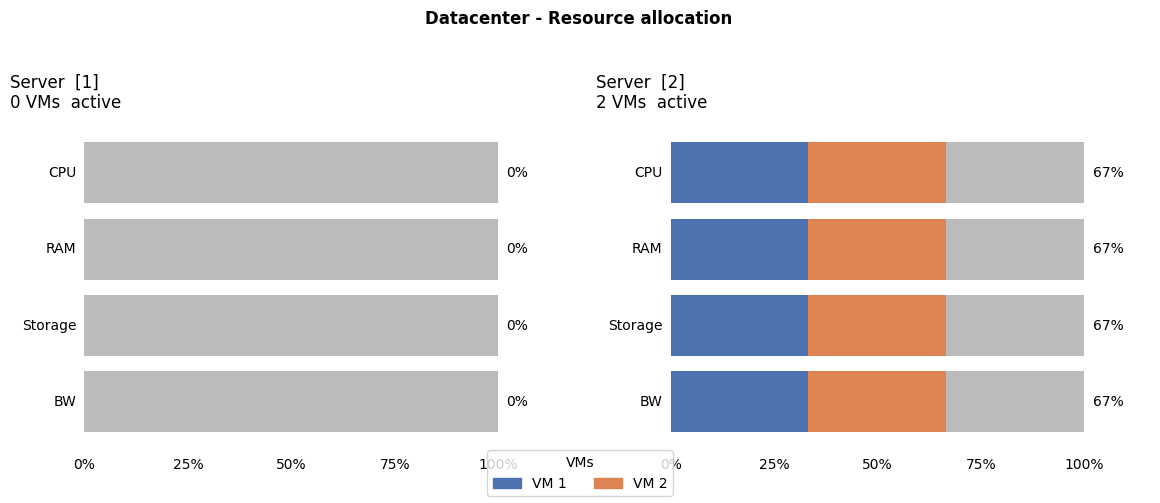

In [3]:
initial_context, solution = test_case_1(CPSATSolver(0.5, 0.5))
initial_context.plot()

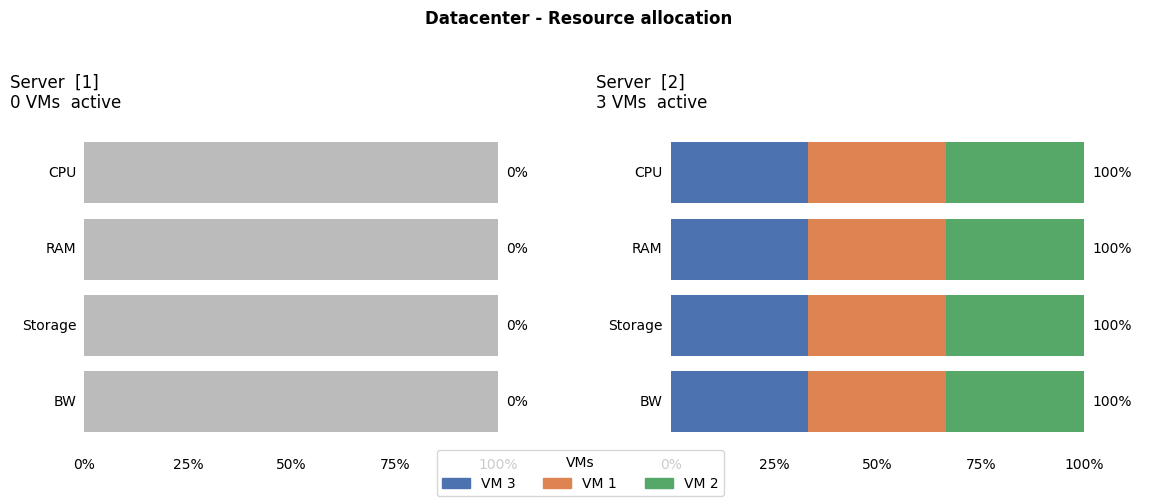

In [4]:
solution.plot()

### FFD

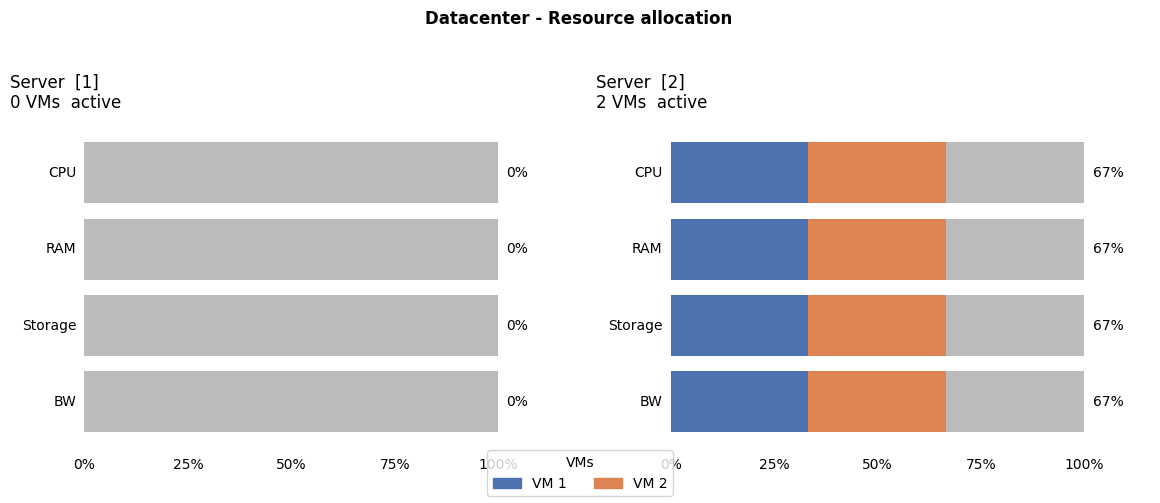

In [5]:
initial_context, solution = test_case_1(FFDSolver())
initial_context.plot()

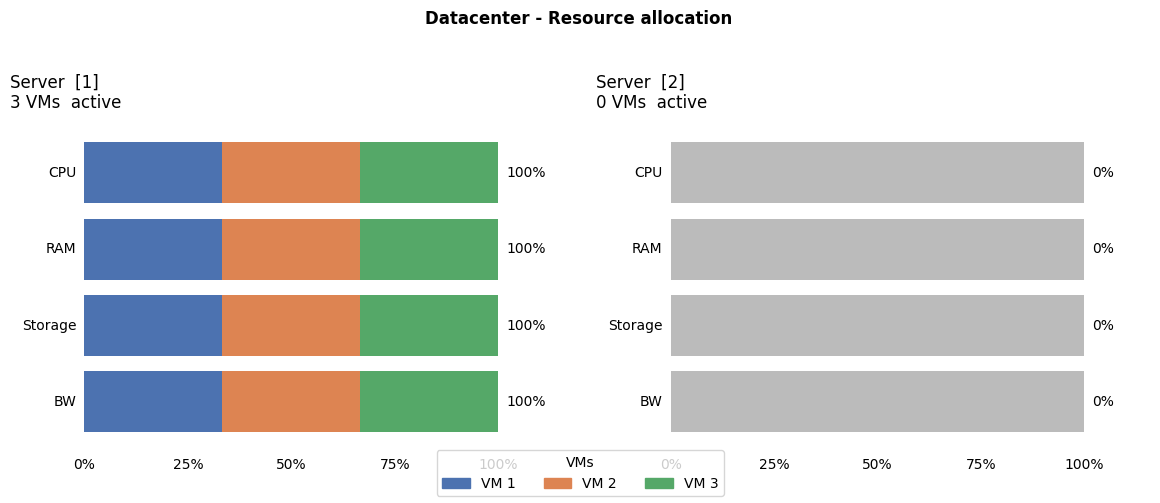

In [6]:
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

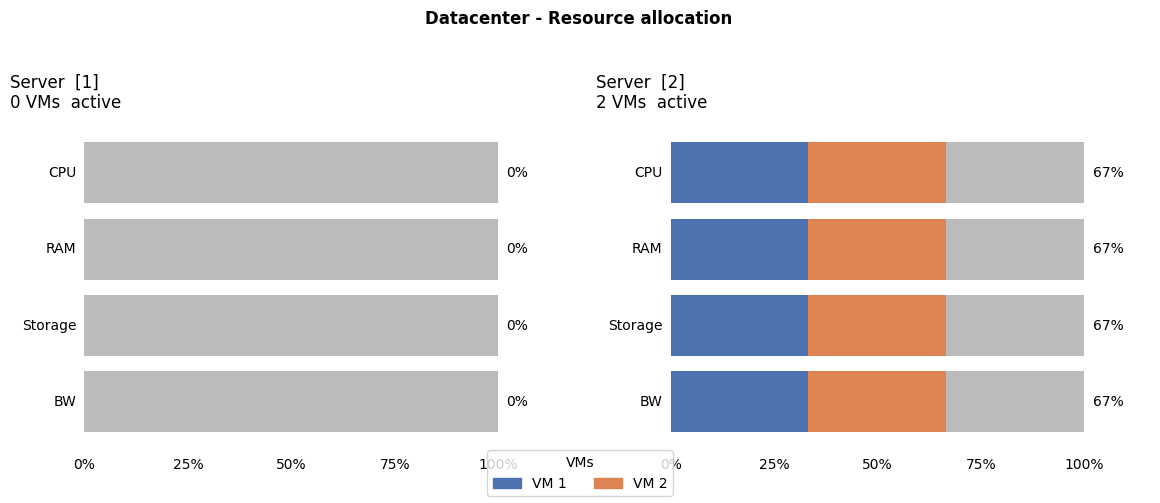

In [7]:
initial_context, solution = test_case_1(PLNESolver(0.5, 0.5))
initial_context.plot()

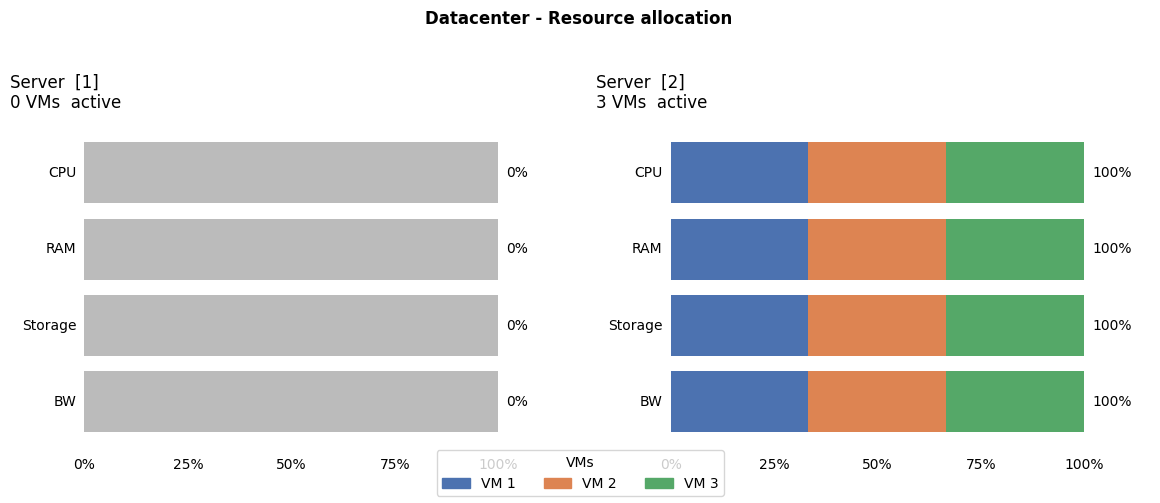

In [8]:
solution.plot()

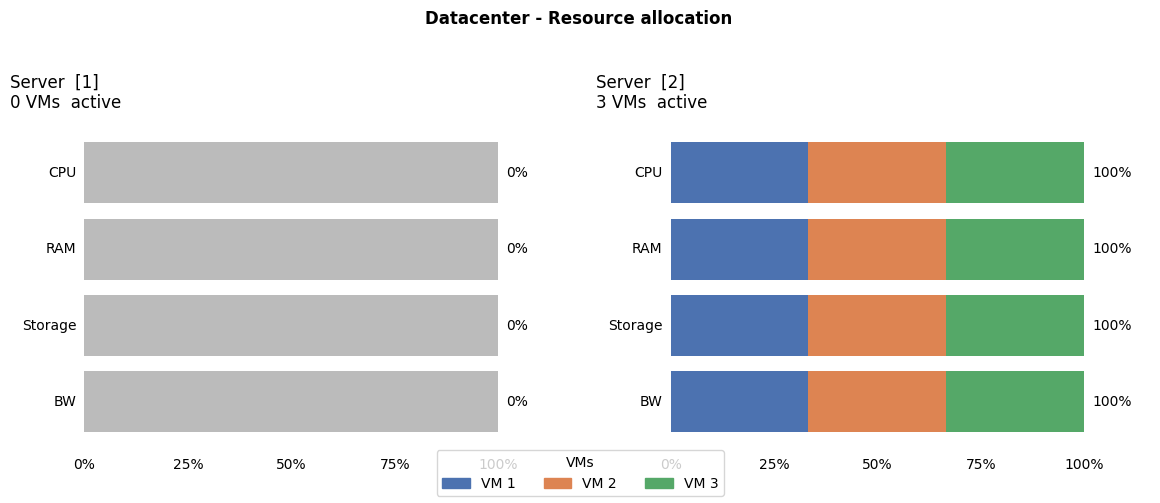

In [9]:
solution.plot()

## Test Case 2 : Simple affinity insertion

Let there be 2 servers of sizes [2, 2] with VMs of sizes [1, 1] in both. We provide another VM of size 1 linked to the one present in the second server. The optimal solution should be to fill the second server without moving anything.

In [10]:
def test_case_2(solver: Solver) -> tuple[Context, Context]:
    first_server = Server(1, 2,2,2,2)
    second_server = Server(2, 2,2,2,2)
    first_server.add_vm(VM(1, 1,1,1,1))
    linked_vm = VM(2, 1,1,1,1)
    second_server.add_vm(linked_vm)
    context = Context([first_server, second_server])
    vms = [VM(3, 1, 1, 1, 1)]
    vms[0].add_affinity(linked_vm)
    solution = solver.solve(vms, context)
    if solution is None:
        return context, context
    return context, solution

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

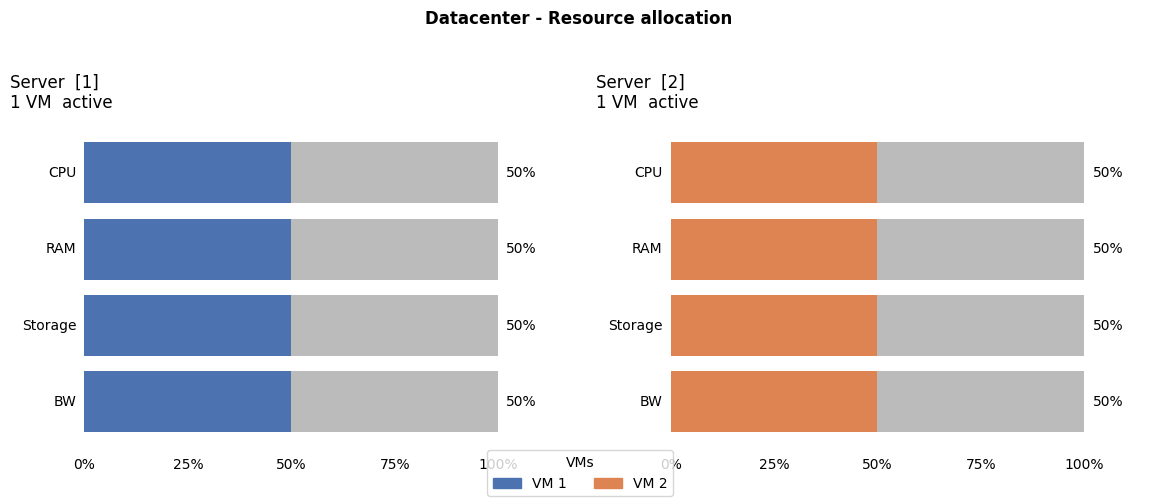

In [11]:
initial_context, solution = test_case_2(CPSATSolver(0.5, 0.5))
initial_context.plot()

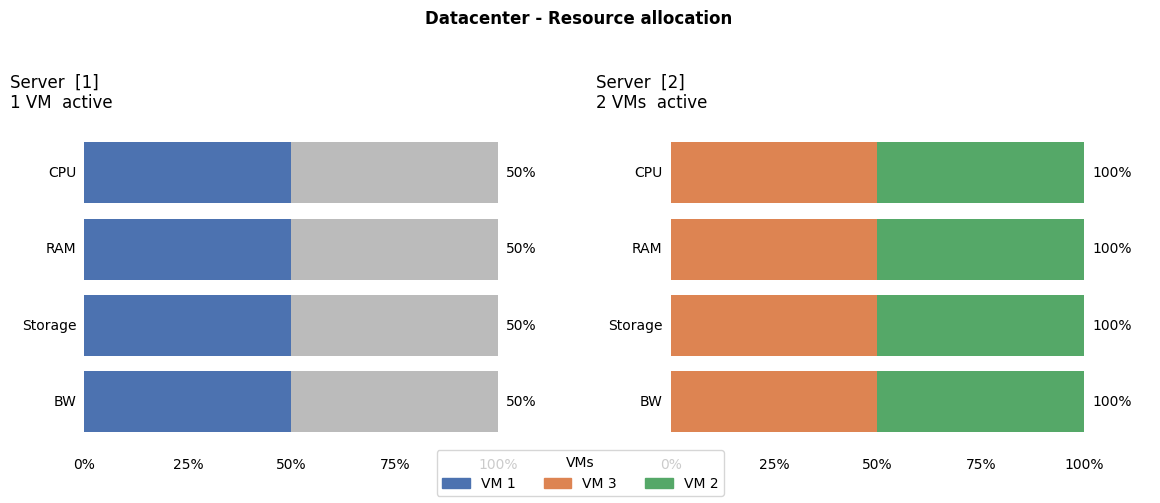

In [12]:
solution.plot()

### FFD

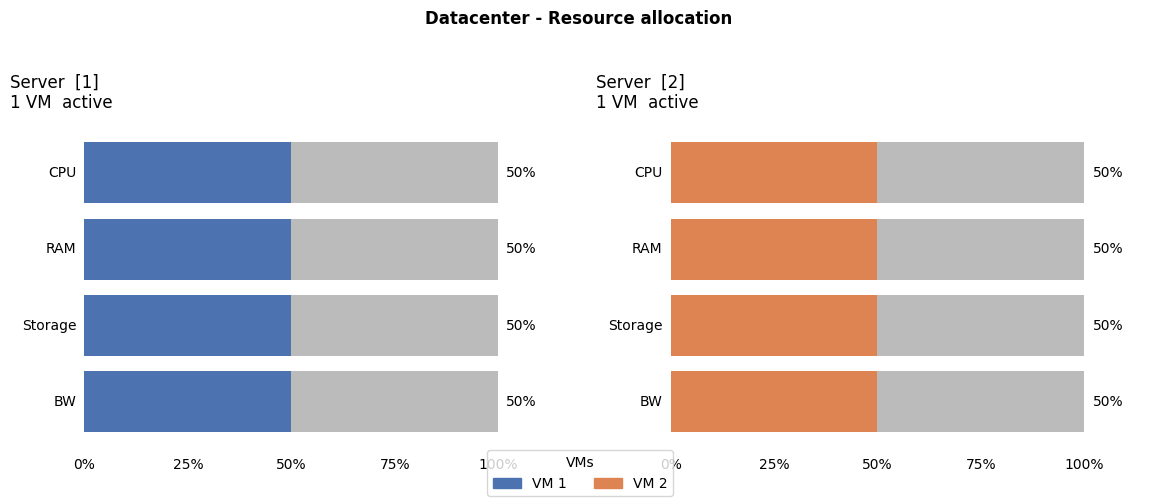

In [13]:
initial_context, solution = test_case_2(FFDSolver())
initial_context.plot()

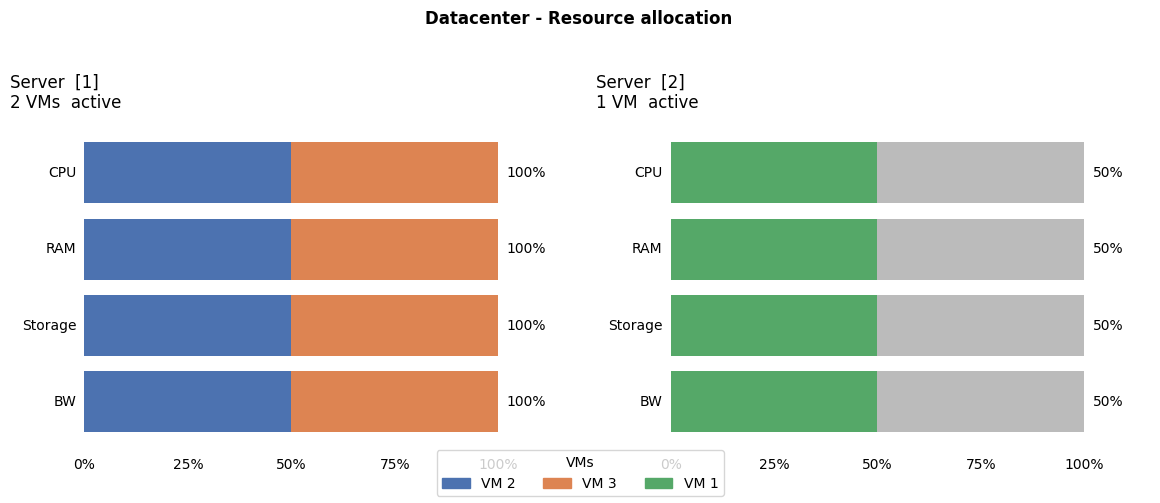

In [14]:
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

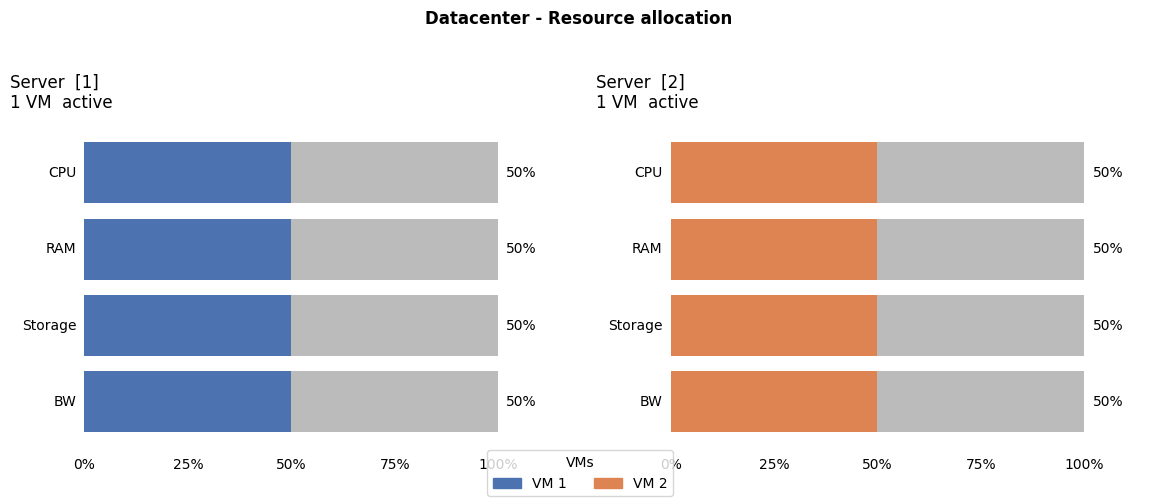

In [15]:
initial_context, solution = test_case_2(PLNESolver(0.5, 0.5))
initial_context.plot()

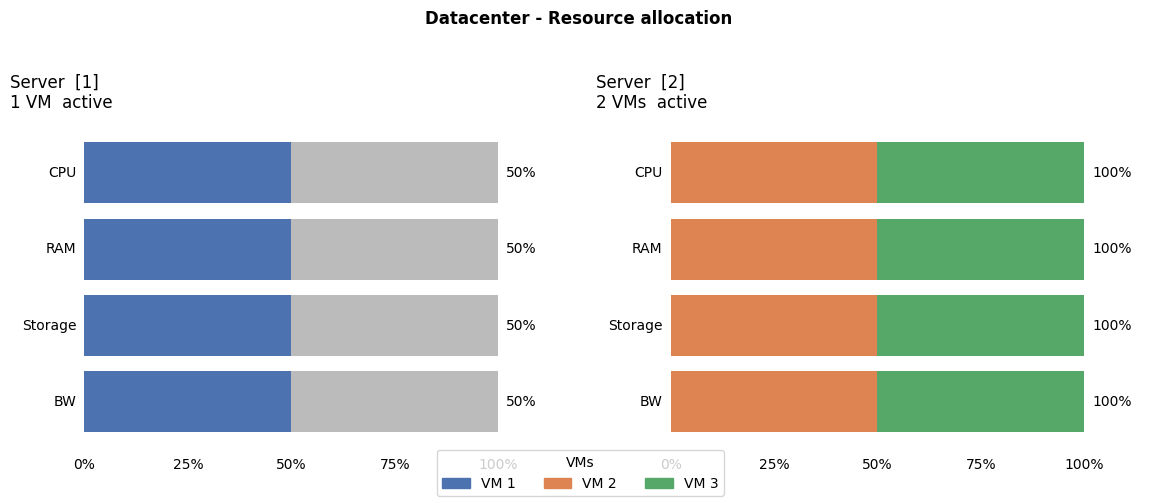

In [16]:
solution.plot()

## Test Case 3 : Simple anti-affinity insertion

Let there be 2 servers of sizes [2, 2] with a VM of size 1 in the second. We provide another VM of size 1 anti-linked to the other. The optimal solution should be to use both servers without moving the already present vm.

In [17]:
def test_case_3(solver: Solver) -> tuple[Context, Context]:
    first_server = Server(1, 2,2,2,2)
    second_server = Server(2, 2,2,2,2)
    linked_vm = VM(1, 1,1,1,1)
    second_server.add_vm(linked_vm)
    context = Context([first_server, second_server])
    vms = [VM(2, 1, 1, 1, 1)]
    vms[0].add_anti_affinity(linked_vm)
    solution = solver.solve(vms, context)
    if solution is None:
        return context, context
    return context, solution

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

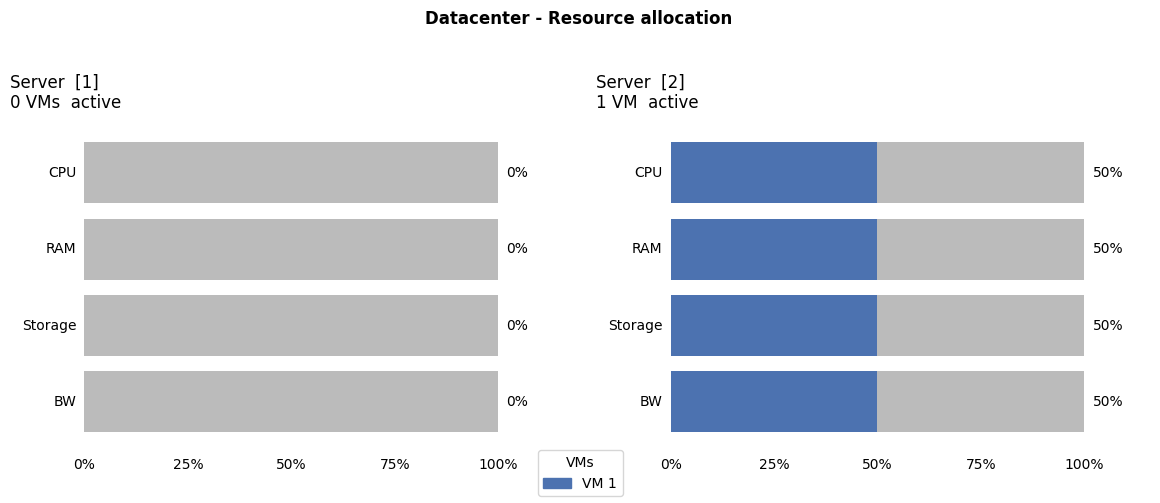

In [18]:
initial_context, solution = test_case_3(CPSATSolver(0.5, 0.5))
initial_context.plot()

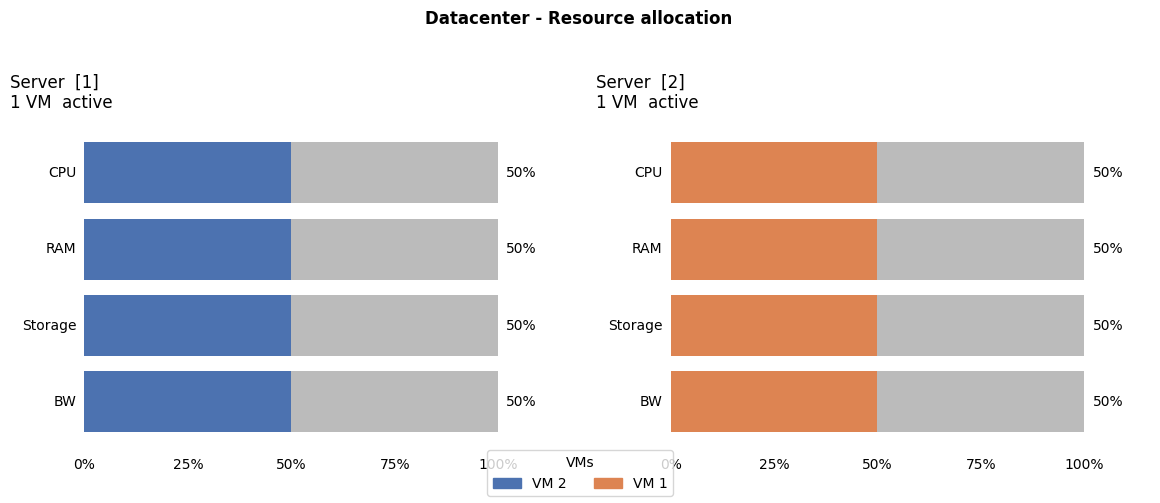

In [19]:
solution.plot()

### FFD

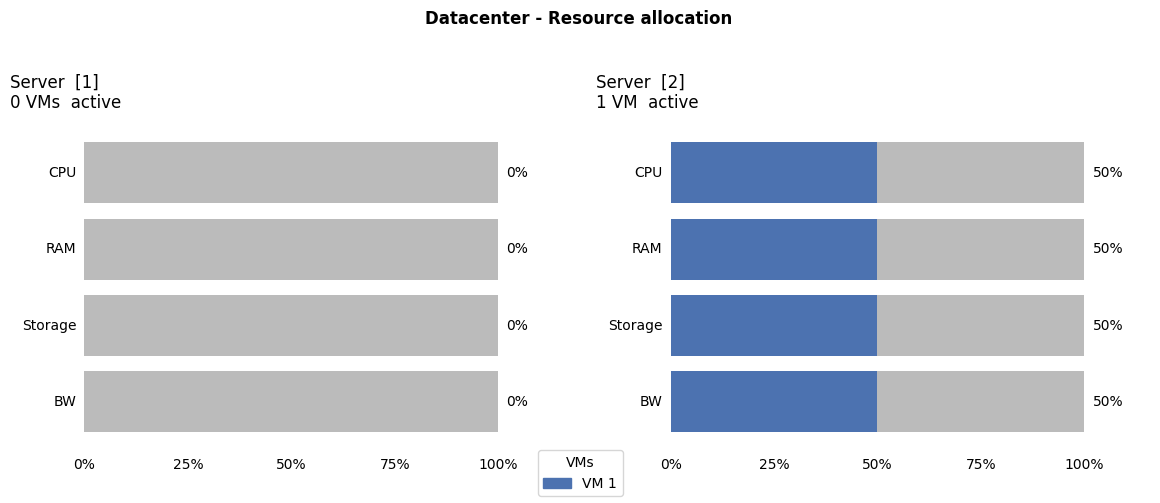

In [20]:
initial_context, solution = test_case_3(FFDSolver())
initial_context.plot()

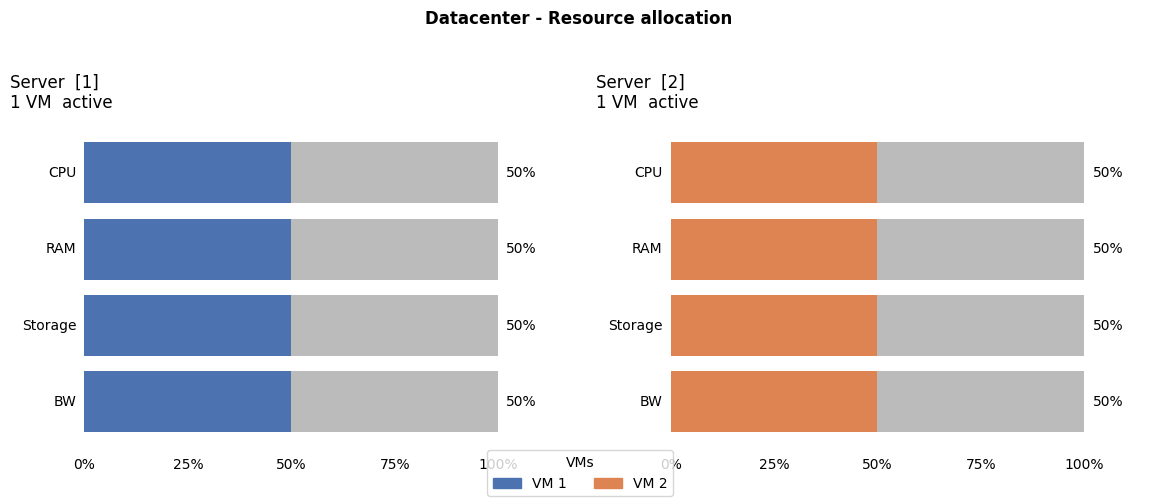

In [21]:
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

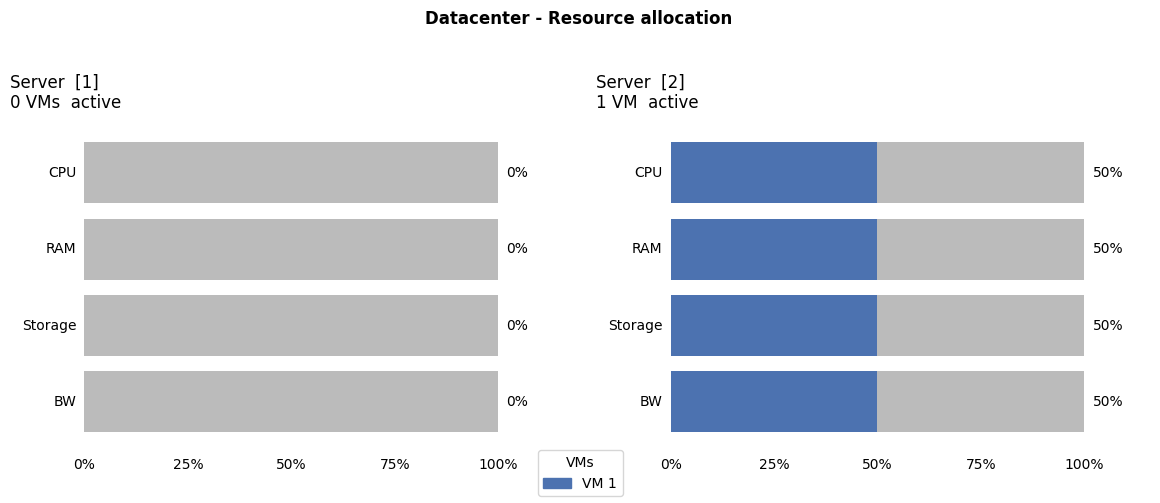

In [22]:
initial_context, solution = test_case_3(PLNESolver(0.5, 0.5))
initial_context.plot()

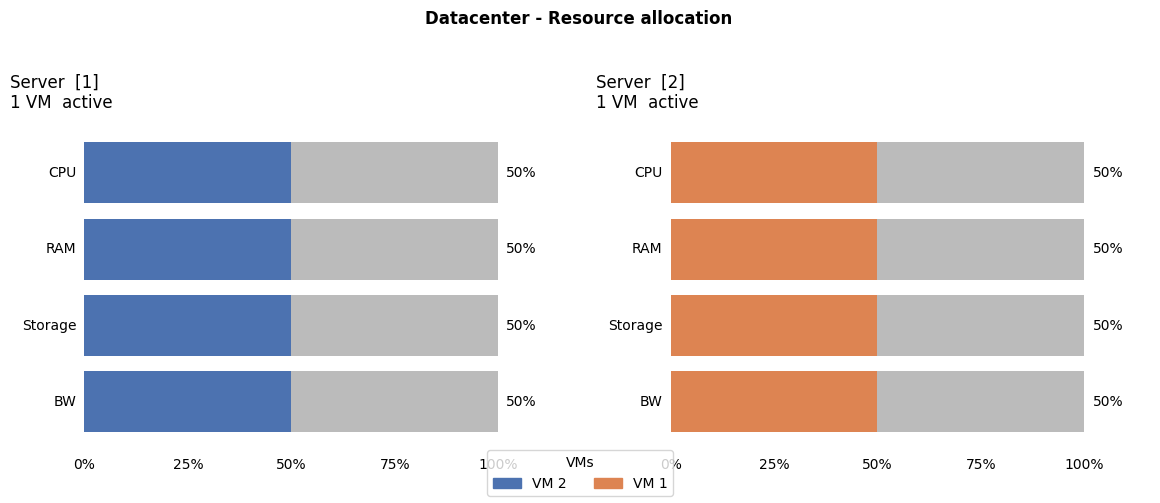

In [23]:
solution.plot()

## Test Case 4 : Necessary hot-swap

Let there be 3 servers of sizes [3, 3, 3] with VMs of sizes [1, 1] in the first and 2 in the second. We provide another VM of size 2. The optimal solution should be to move one of the vm of size 1 to the second server to use only two servers.

In [24]:
def test_case_4(solver: Solver) -> tuple[Context, Context]:
    first_server = Server(1, 3,3,3,3)
    second_server = Server(2, 3,3,3,3)
    first_server.add_vm(VM(1, 1, 1, 1, 1))
    first_server.add_vm(VM(2, 1, 1, 1, 1))
    second_server.add_vm(VM(3, 2, 2, 2, 2))
    context = Context([first_server, second_server, Server(3, 3, 3, 3, 3)])
    vms = [VM(4, 2, 2, 2, 2)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, context
    return context, solution

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

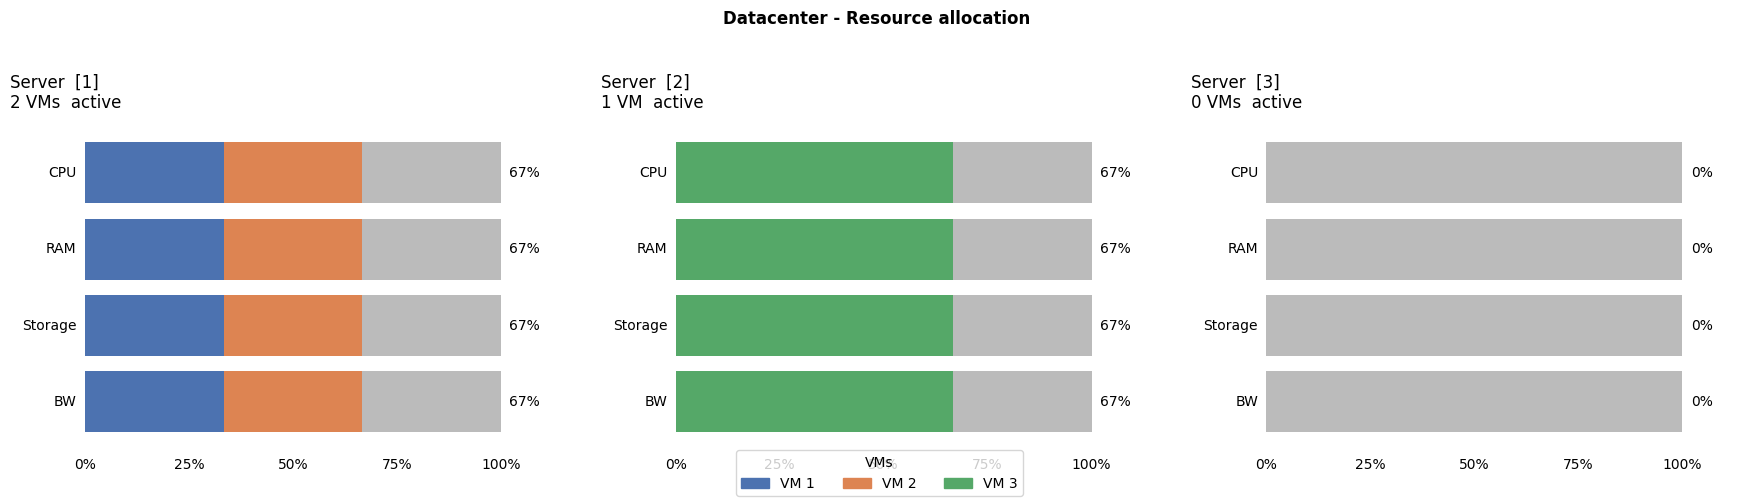

In [25]:
initial_context, solution = test_case_4(CPSATSolver(0.5, 0.5))
initial_context.plot()

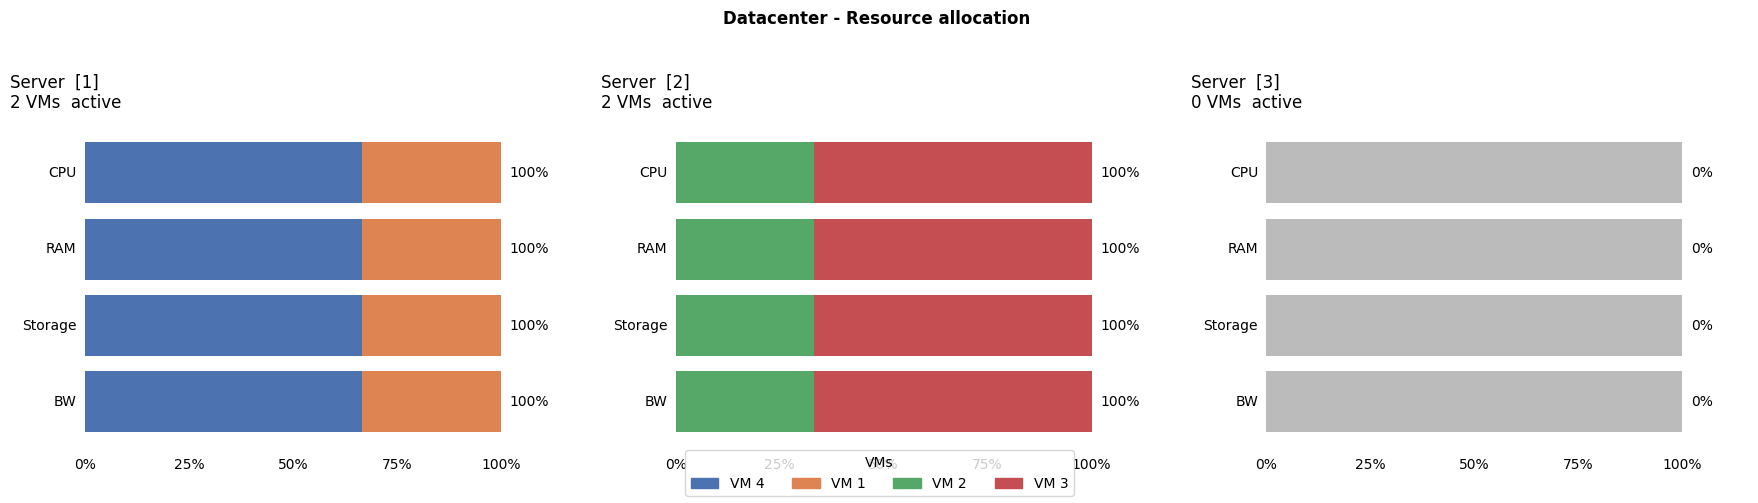

In [26]:
solution.plot()

### CP-SAT (migration weight = 2, fragmentation weight = 0.5)

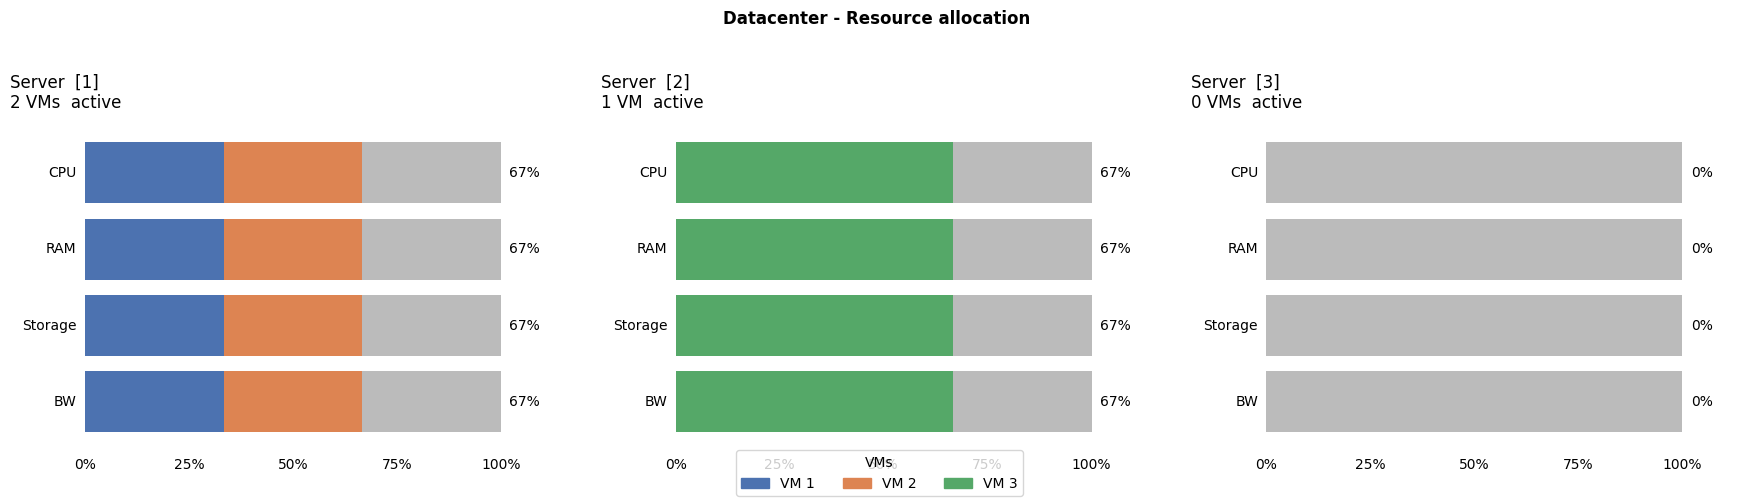

In [27]:
initial_context, solution = test_case_4(CPSATSolver(2, 0.5))
initial_context.plot()

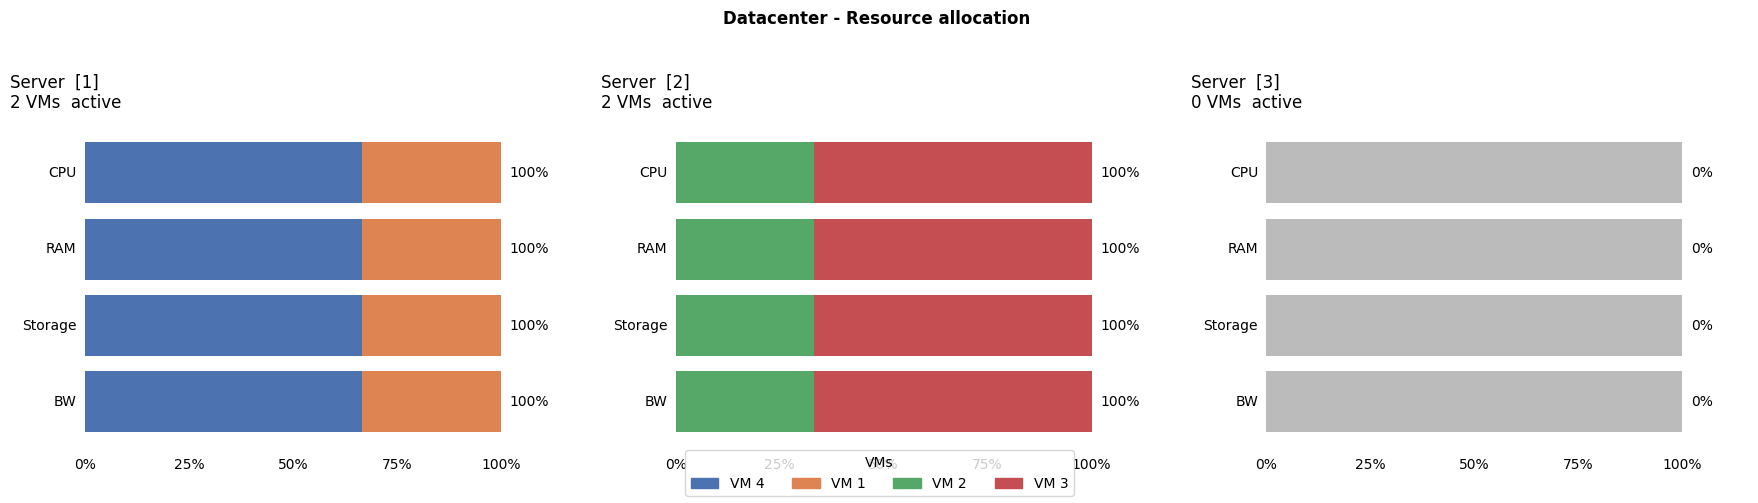

In [28]:
solution.plot()

### FFD

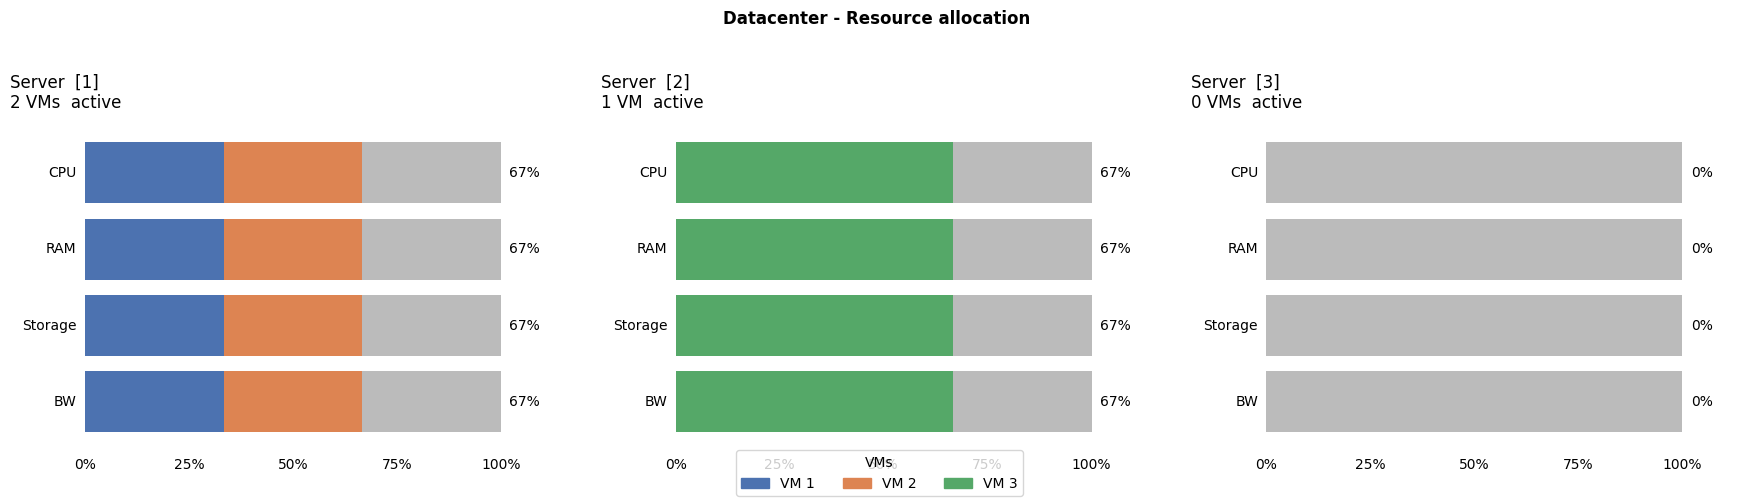

In [29]:
initial_context, solution = test_case_4(FFDSolver())
initial_context.plot()

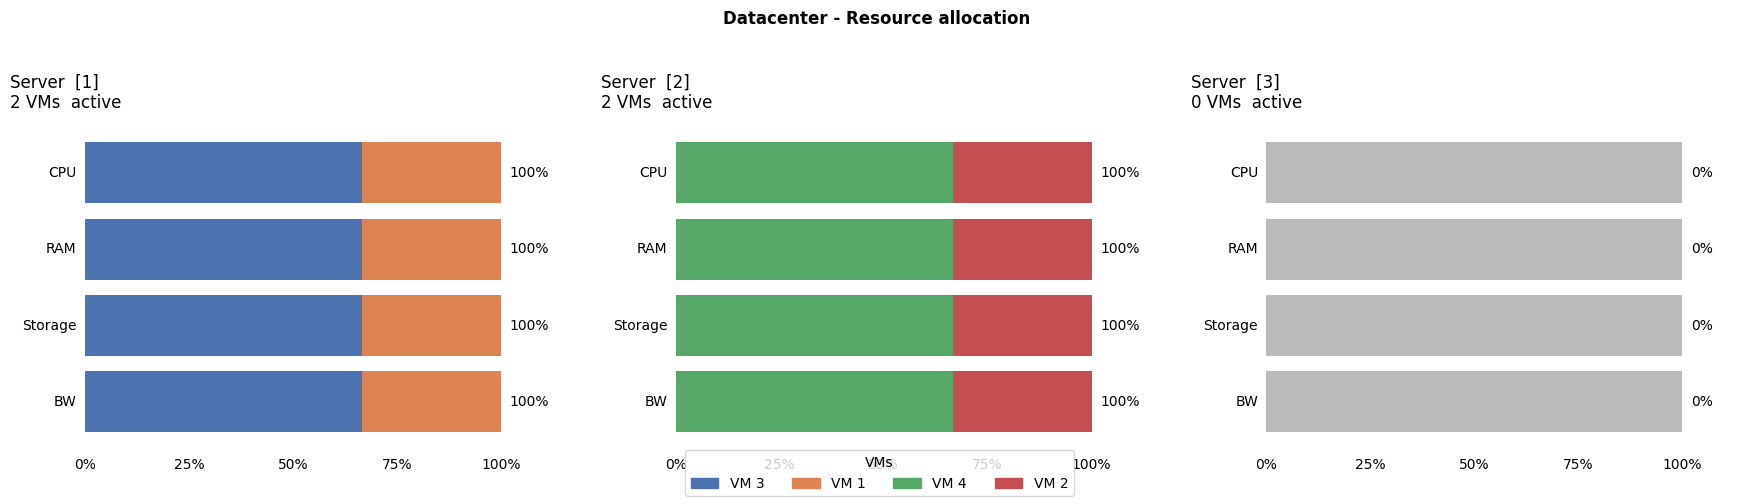

In [30]:
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

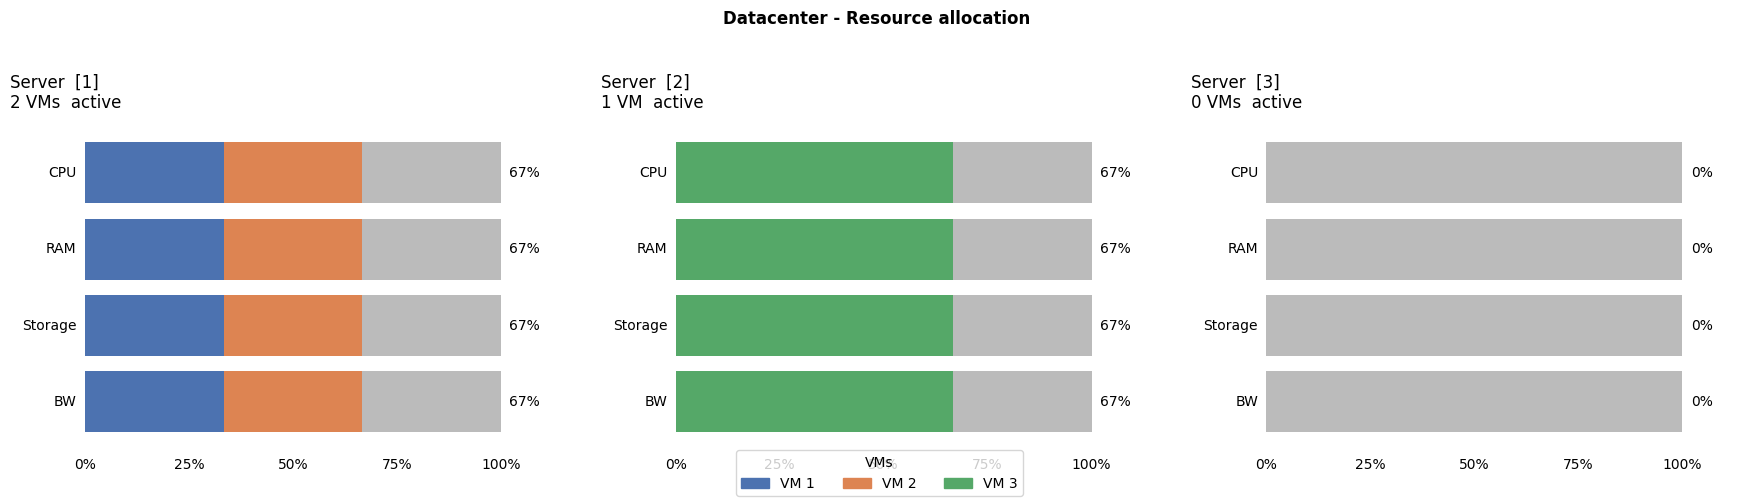

In [31]:
initial_context, solution = test_case_4(PLNESolver(0.5, 0.5))
initial_context.plot()

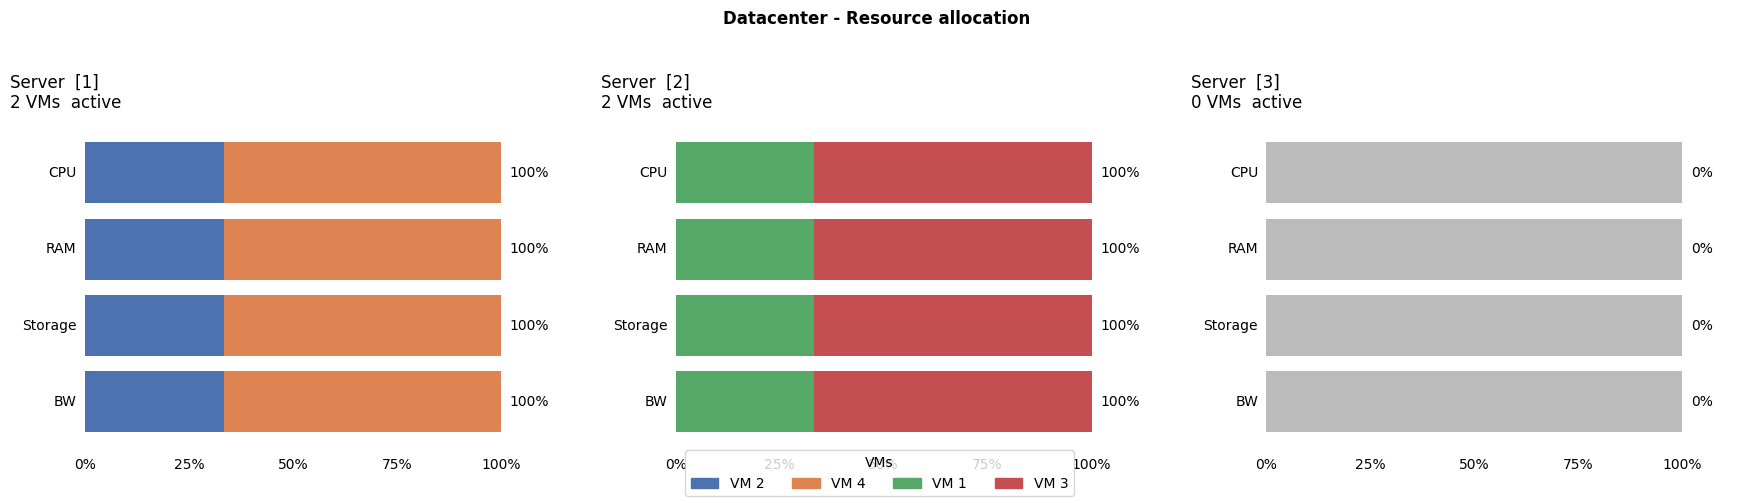

In [32]:
solution.plot()

## Test Case 5 : Preferable hot-swap

Let there be 2 servers of sizes [4, 4] with VMs of sizes [1, 2] in the first and 1 in the second. We provide another VM of size 2. The optimal solution should be to move the vm of size 1 from the second server or move the vm of size 1 from the first server to decrease fragmentation.

In [33]:
def test_case_5(solver: Solver) -> tuple[Context, Context]:
    first_server = Server(1, 4,4, 4,4)
    second_server = Server(2, 4,4, 4,4)
    first_server.add_vm(VM(1, 1, 1, 1, 1))
    first_server.add_vm(VM(2, 2,2, 2,2))
    second_server.add_vm(VM(3, 1, 1, 1, 1))
    context = Context([first_server, second_server])
    vms = [VM(4, 2, 2, 2, 2)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, context
    return context, solution

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

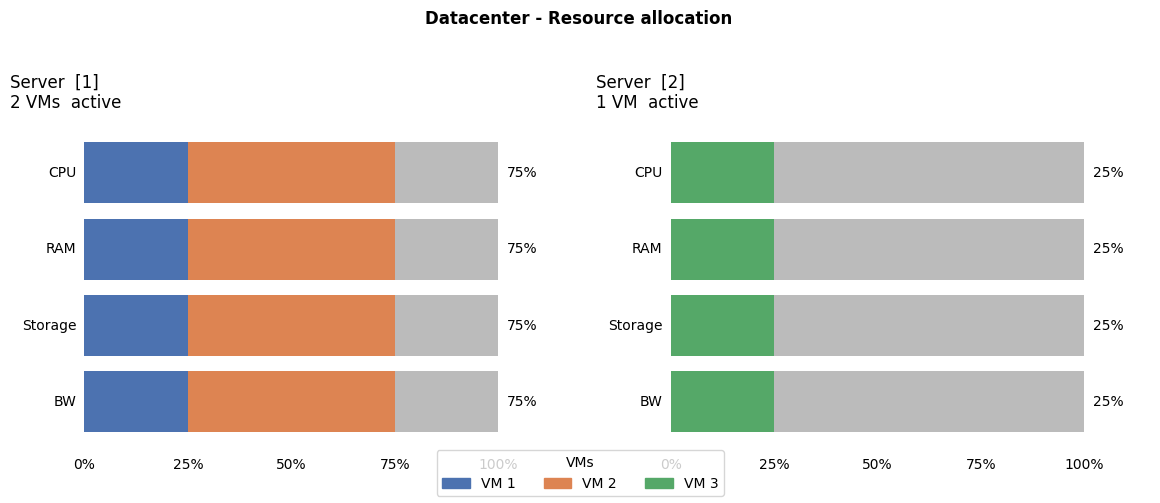

In [34]:
initial_context, solution = test_case_5(CPSATSolver(0.5, 0.5))
initial_context.plot()

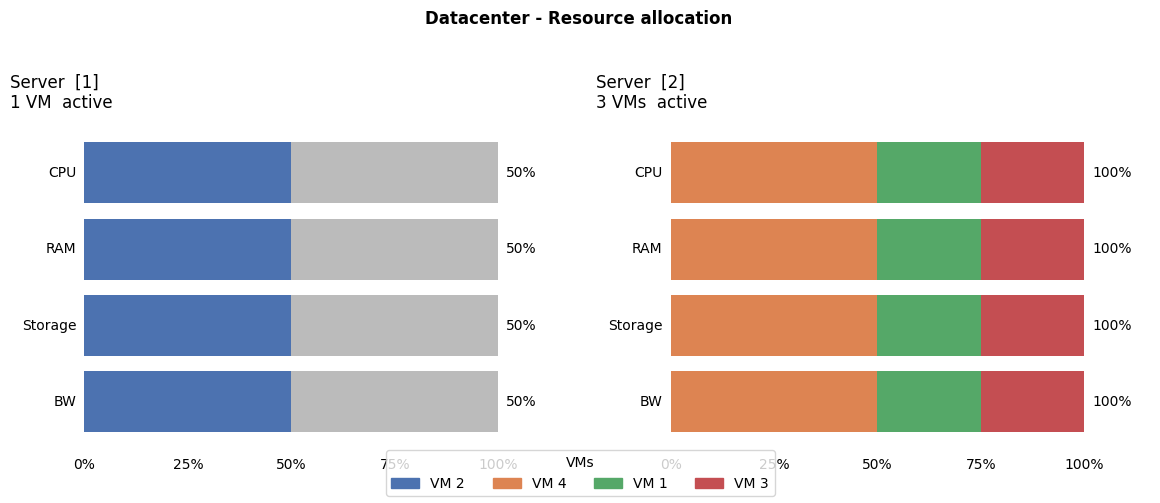

In [35]:
solution.plot()

### CP-SAT (migration weight = 0.2, fragmentation weight = 0.8)

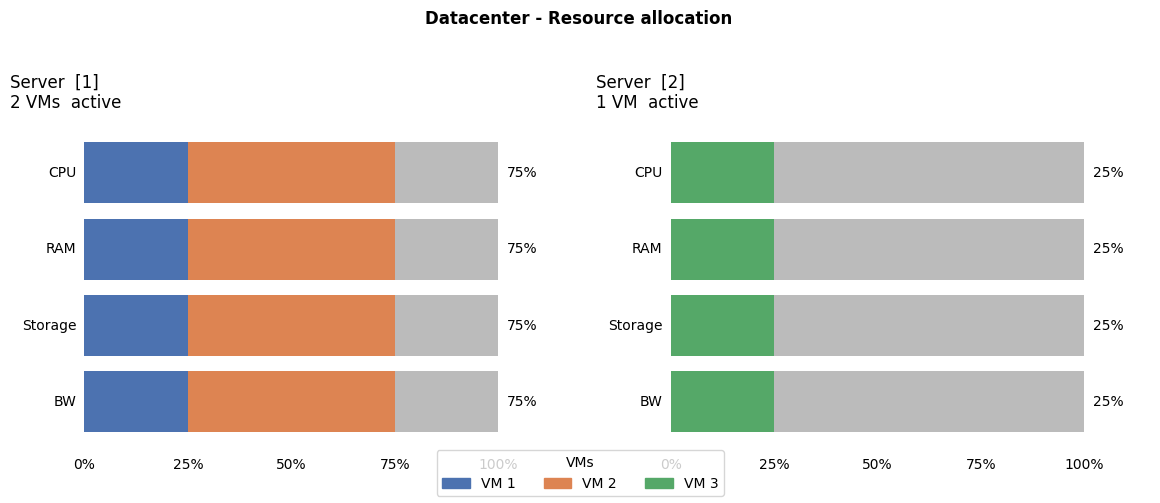

In [36]:
initial_context, solution = test_case_5(CPSATSolver(0.2, 0.8))
initial_context.plot()

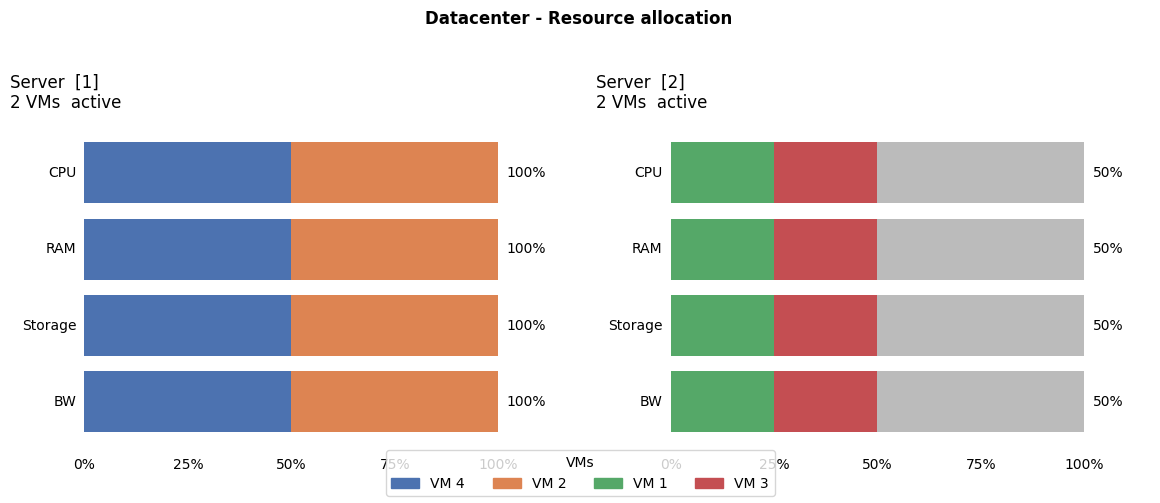

In [37]:
solution.plot()

### FFD

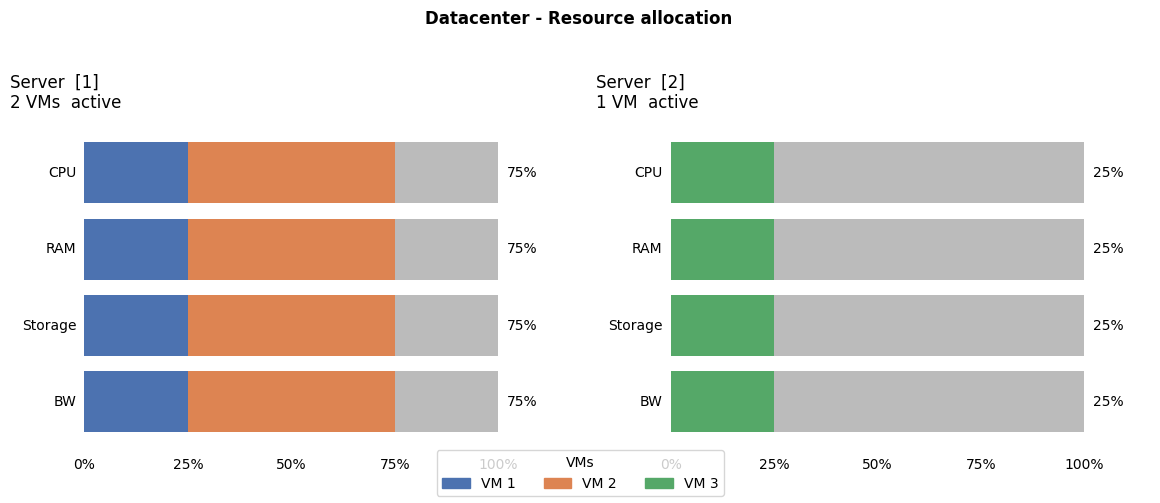

In [38]:
initial_context, solution = test_case_5(FFDSolver())
initial_context.plot()

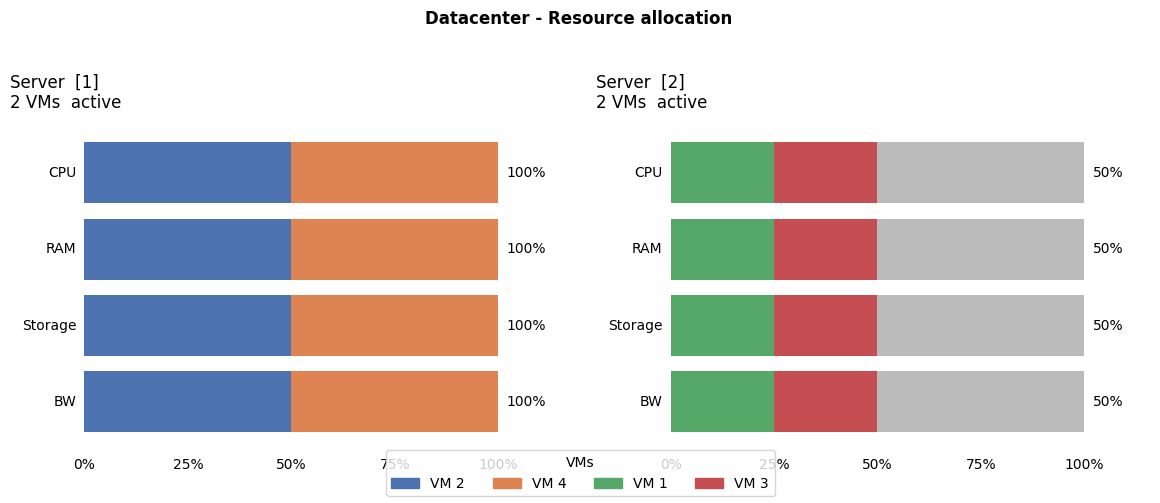

In [39]:
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

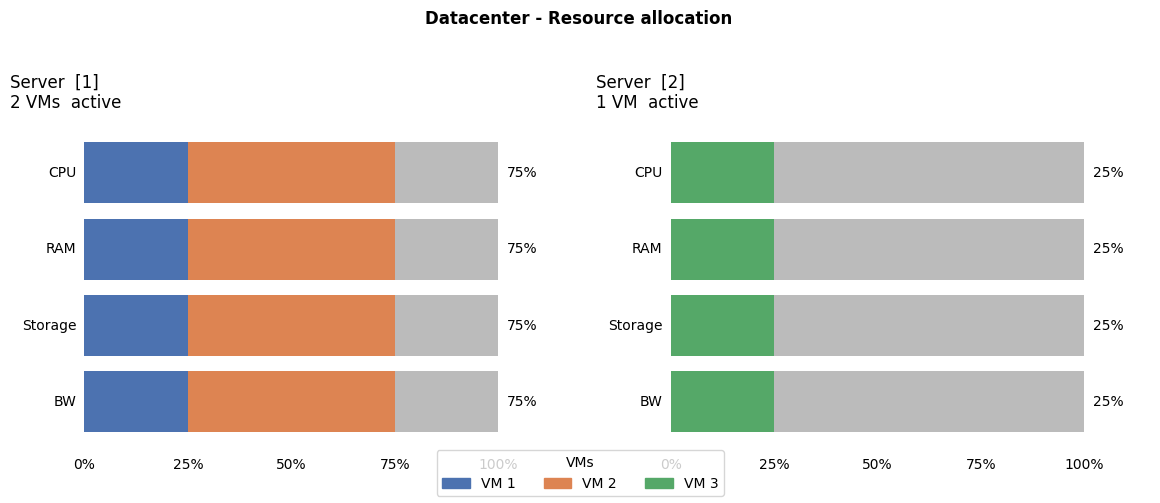

In [40]:
initial_context, solution = test_case_5(PLNESolver(0.5, 0.5))
initial_context.plot()

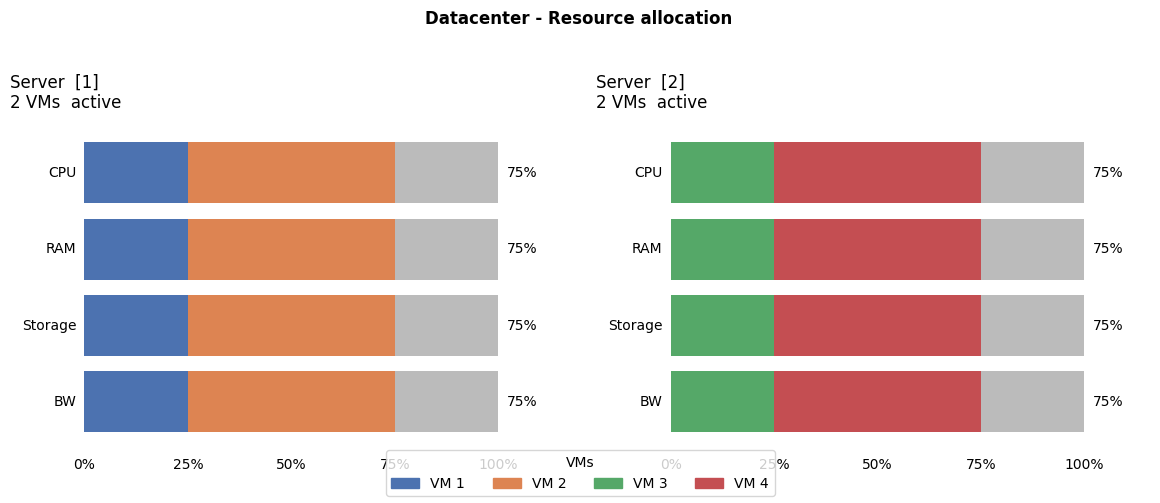

In [41]:
solution.plot()

### PLNE (migration weight = 0.2, fragmentation weight = 0.8)

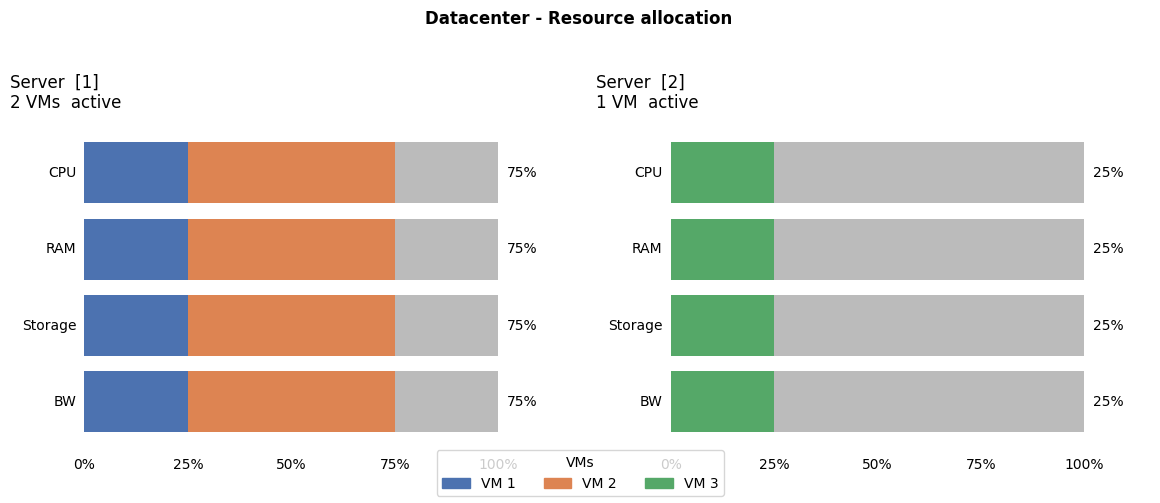

In [42]:
initial_context, solution = test_case_5(PLNESolver(0.2, 0.8))
initial_context.plot()

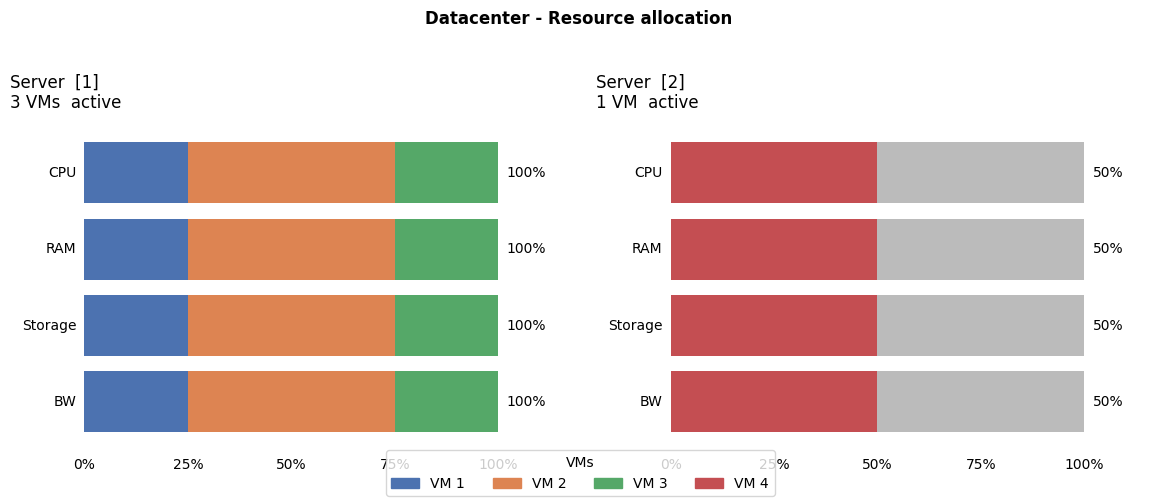

In [43]:
solution.plot()